In [ ]:
#%pip install roboflow

  Using cached roboflow-1.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pillow_avif_plugin-1.6.0-cp312-cp312-win_amd64.whl.metadata (2.3 kB)
  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached py


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


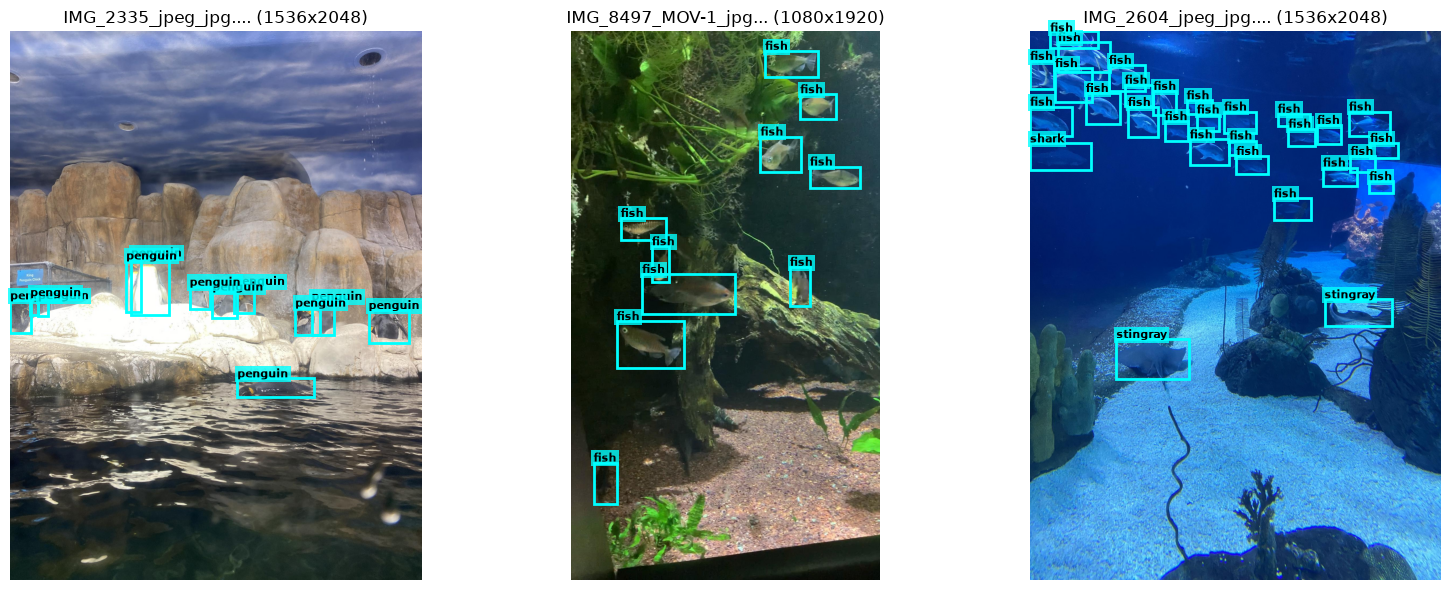

In [3]:
import json
import os
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

# Ruta al conjunto de entrenamiento
dataset_dir = "Aquarium-Combined-6/train"
ann_path = os.path.join(dataset_dir, "_annotations.coco.json")

with open(ann_path, "r") as f:
    coco_data = json.load(f)

# Diccionarios de mapeo
categories = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
img_to_anns = {}
for ann in coco_data["annotations"]:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

# Seleccionar 3 imágenes al azar con anotaciones
images_with_anns = [
    img for img in coco_data["images"] if img["id"] in img_to_anns
]
sample_images = random.sample(images_with_anns, min(3, len(images_with_anns)))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, img_info in zip(axes, sample_images):
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{img_info['file_name'][:18]}... ({img_info['width']}x{img_info['height']})"
    )

    for ann in img_to_anns.get(img_info["id"], []):
        # Formato COCO bbox: [x_min, y_min, width, height]
        x, y, w, h = ann["bbox"]
        label = categories.get(ann["category_id"], "Obj")

        rect = patches.Rectangle(
            (x, y), w, h, linewidth=2, edgecolor="cyan", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x,
            max(0, y - 4),
            label,
            color="black",
            fontsize=8,
            weight="bold",
            bbox=dict(
                boxstyle="square,pad=0.2",
                facecolor="cyan",
                edgecolor="none",
                alpha=0.8,
            ),
        )

plt.tight_layout()
plt.show()

# **Modulo 1:** Backbone que expone mapa espacial

Especificación: sea F(x) = f4(f3(f2(f1(x)))) la composición de los 4 bloques convolucionales de FundidoraPC, cada uno Conv3×3 → BatchNorm → ReLU → MaxPool2×2. 
Actualmente el forward aplica GlobalAvgPool(F(x)) y retorna un vector de dimensión 256. Para el RPN se necesitan ambas salidas; el vector pooled (compatibilidad con clasificación) y el mapa F(x) ∈ R^{256×H×W} sin poolear.
Tarea: modificar FundidoraPC.forward para que retorne una tupla (pooled: Tensor[B,256], feature_map: Tensor[B,256,H,W]). No cambiar out_features ni la firma de construcción del backbone  DualHeadDetector debe seguir funcionando llamando solo al primer elemento de la tupla.
Criterio de aceptación: con una imagen de 224×224 de entrada, feature_map.shape debe ser [B, 256, 14, 14] (4 MaxPool de stride 2 → 224/16=14). Si el H,W no da 14, revisar que no se esté agregando un pooling extra.

In [1]:
import torch
import torch.nn as nn

class FundidoraPC(nn.Module):
    '''
    Backbone extractor de características modificado para Taller 3.
    4 bloques conv -> BN -> ReLU -> MaxPool.
    Retorna tanto el vector global promediado como el mapa espacial sin colapsar.
    '''
    def __init__(self, in_channels=3):
        super().__init__()
        # Bloque 1: (B, 3, 224, 224) -> (B, 32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Bloque 2: (B, 32, 112, 112) -> (B, 64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Bloque 3: (B, 64, 56, 56) -> (B, 128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Bloque 4: (B, 128, 28, 28) -> (B, 256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        # Pooling global adaptativo (mantiene compatibilidad previa)
        self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.out_features = 256

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        feature_map = self.pool4(torch.relu(self.bn4(self.conv4(x)))) # [B, 256, 14, 14]

        # Vector colapsado para clasificación/compatibilidad: [B, 256]
        pooled = self.global_pool(feature_map).flatten(start_dim=1)

        return pooled, feature_map

In [2]:
# Verificación de formas y criterios de aceptación
dummy_input = torch.randn(4, 3, 224, 224)
model_backbone = FundidoraPC()
pooled_out, feat_map = model_backbone(dummy_input)

print(f"Shape pooled:      {pooled_out.shape} -> Esperado: (4, 256)")
print(f"Shape feature_map: {feat_map.shape} -> Esperado: (4, 256, 14, 14)")

# Aserciones estrictas
assert pooled_out.shape == (4, 256), f"Error en pooled: {pooled_out.shape}"
assert feat_map.shape == (4, 256, 14, 14), f"Error en feature_map: {feat_map.shape}"
assert hasattr(model_backbone, 'out_features') and model_backbone.out_features == 256, "out_features modificado"

# Verificación de compatibilidad con DualHeadDetector (tomando elemento 0)
class DualHeadDetectorTest(nn.Module):
    def __init__(self, backbone, num_classes=3):
        super().__init__()
        self.backbone = backbone
        self.cls_head = nn.Linear(backbone.out_features, num_classes)
        self.bbox_head = nn.Linear(backbone.out_features, 4)

    def forward(self, x):
        # Llama a la tupla y toma solo el primer elemento
        v = self.backbone(x)[0]
        return self.cls_head(v), torch.sigmoid(self.bbox_head(v))

test_dual = DualHeadDetectorTest(model_backbone)
logits_test, bbox_test = test_dual(dummy_input)
assert logits_test.shape == (4, 3) and bbox_test.shape == (4, 4), "DualHeadDetector falló"
print("\n✓ Criterio de aceptación del Módulo 1 superado exitosamente.")

Shape pooled:      torch.Size([4, 256]) -> Esperado: (4, 256)
Shape feature_map: torch.Size([4, 256, 14, 14]) -> Esperado: (4, 256, 14, 14)

✓ Criterio de aceptación del Módulo 1 superado exitosamente.


In [3]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class AquariumDataset(Dataset):
    """
    Dataset para parsear anotaciones COCO de Roboflow, redimensionar imágenes
    a 224x224 y reescalar las cajas al formato [x1, y1, x2, y2].
    """
    def __init__(self, root_dir, split="train", target_size=(224, 224)):
        super().__init__()
        self.split_dir = os.path.join(root_dir, split)
        self.target_w, self.target_h = target_size
        self.ann_path = os.path.join(self.split_dir, "_annotations.coco.json")

        with open(self.ann_path, "r") as f:
            self.coco_data = json.load(f)

        # Mapeo de categorías (1-indexed a 0-indexed para las clases de objetos)
        self.categories = {cat["id"]: cat["name"] for cat in self.coco_data["categories"]}
        self.cat_id_to_label = {cat_id: idx for idx, cat_id in enumerate(sorted(self.categories.keys()))}
        self.num_classes = len(self.cat_id_to_label)

        # Indexar anotaciones por image_id
        self.img_to_anns = {}
        for ann in self.coco_data["annotations"]:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        # Filtrar imágenes que contengan al menos una anotación válida
        self.images_info = [
            img for img in self.coco_data["images"] if img["id"] in self.img_to_anns
        ]

        self.transform = T.Compose([
            T.Resize(target_size),
            T.ToTensor(),
            # Normalización estándar para convergencia estable
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images_info)

    def __getitem__(self, idx):
        img_info = self.images_info[idx]
        img_path = os.path.join(self.split_dir, img_info["file_name"])
        
        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        # Factores de escala para ajustar coordenadas
        scale_x = self.target_w / orig_w
        scale_y = self.target_h / orig_h

        boxes = []
        labels = []

        for ann in self.img_to_anns.get(img_info["id"], []):
            x, y, w, h = ann["bbox"]

            # Convertir [x, y, w, h] a [x1, y1, x2, y2] escalado
            x1 = x * scale_x
            y1 = y * scale_y
            x2 = (x + w) * scale_x
            y2 = (y + h) * scale_y

            # Asegurar límites dentro de [0, 224]
            x1 = max(0.0, min(float(x1), float(self.target_w)))
            y1 = max(0.0, min(float(y1), float(self.target_h)))
            x2 = max(0.0, min(float(x2), float(self.target_w)))
            y2 = max(0.0, min(float(y2), float(self.target_h)))

            # Filtrar cajas degeneradas con ancho o alto menor a 2 píxeles
            if (x2 - x1) >= 2.0 and (y2 - y1) >= 2.0:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.cat_id_to_label[ann["category_id"]])

        # Si todas las cajas fueran descartadas, evitar tensor vacío degenerado
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        img_tensor = self.transform(img)
        target = {"boxes": boxes, "labels": labels, "image_id": img_info["id"]}

        return img_tensor, target


def collate_fn_multiobject(batch):
    """
    Agrupa tensores de imágenes [B, 3, 224, 224] y mantiene los targets como tupla/lista
    de diccionarios para manejar número arbitrario de objetos por imagen.
    """
    images = torch.stack([item[0] for item in batch], dim=0)
    targets = [item[1] for item in batch]
    return images, targets

In [4]:
# Ajustar con el nombre exacto de la carpeta generada por Roboflow
DATASET_PATH = "Aquarium-Combined-6"

train_dataset = AquariumDataset(root_dir=DATASET_PATH, split="train", target_size=(224, 224))
val_dataset = AquariumDataset(root_dir=DATASET_PATH, split="valid", target_size=(224, 224))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn_multiobject
)

print(f"Número total de imágenes de train: {len(train_dataset)}")
print(f"Número total de imágenes de valid: {len(val_dataset)}")
print(f"Clases detectadas ({train_dataset.num_classes}): {list(train_dataset.categories.values())}")

# Probar extracción de un batch
sample_images, sample_targets = next(iter(train_loader))

print(f"\nBatch imágenes shape: {sample_images.shape} -> Esperado: (4, 3, 224, 224)")
print(f"Número de targets en batch: {len(sample_targets)}")
for i, target in enumerate(sample_targets):
    print(f"  Img {i} -> {len(target['boxes'])} objetos | Cajas shape: {target['boxes'].shape}")

# Prueba de integración directa con FundidoraPC
with torch.no_grad():
    pooled, feat_map = model_backbone(sample_images)

assert feat_map.shape == (4, 256, 14, 14), "Error: feat_map no coincide con (4, 256, 14, 14)"
print("\n✓ Pipeline de datos y enlace con el Backbone funcionando correctamente.")

Número total de imágenes de train: 447
Número total de imágenes de valid: 127
Clases detectadas (8): ['creatures', 'fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']

Batch imágenes shape: torch.Size([4, 3, 224, 224]) -> Esperado: (4, 3, 224, 224)
Número de targets en batch: 4
  Img 0 -> 1 objetos | Cajas shape: torch.Size([1, 4])
  Img 1 -> 2 objetos | Cajas shape: torch.Size([2, 4])
  Img 2 -> 1 objetos | Cajas shape: torch.Size([1, 4])
  Img 3 -> 5 objetos | Cajas shape: torch.Size([5, 4])

✓ Pipeline de datos y enlace con el Backbone funcionando correctamente.


### Checkpoint - Módulo 1 (Trazabilidad IA)

* **Qué se le pidió a la IA (Prompt tal cual):**
  "Necesito modificar la clase FundidoraPC de Semana 6 para que en su forward retorne una tupla con dimensiones [B, 256] y [B, 256, 14, 14] para entradas de 224x224, sin alterar out_features ni romper la compatibilidad con DualHeadDetector, siguiendo la metodología de verificar primero dimensiones con tensores sintéticos antes de entrenar."

* **Qué devolvió la IA (Fragmento sin editar):**
  ```python
  class FundidoraPC(nn.Module):
      def __init__(self, in_channels=3):
          super().__init__()
          self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
          self.bn1 = nn.BatchNorm2d(32)
          self.pool1 = nn.MaxPool2d(kernel_size=2)
          self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
          self.bn2 = nn.BatchNorm2d(64)
          self.pool2 = nn.MaxPool2d(kernel_size=2)
          self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
          self.bn3 = nn.BatchNorm2d(128)
          self.pool3 = nn.MaxPool2d(kernel_size=2)
          self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
          self.bn4 = nn.BatchNorm2d(256)
          self.pool4 = nn.MaxPool2d(kernel_size=2)
          self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
          self.out_features = 256

      def forward(self, x):
          x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
          x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
          x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
          feature_map = self.pool4(torch.relu(self.bn4(self.conv4(x))))
          pooled = self.global_pool(feature_map).flatten(start_dim=1)
          return pooled, feature_map